# Análisis de Clustering: Descubrimiento de Distribuciones Latentes
## Identificación de patrones ocultos en datos agrícolas

---

### Objetivo
Utilizar algoritmos de clustering para:
1. **Descubrir grupos naturales** en los datos de rendimiento agrícola
2. **Identificar distribuciones latentes** que capturen similitudes entre regiones/años/cultivos
3. **Generar features de clustering** para mejorar modelos predictivos
4. **Reducir dimensionalidad** para visualización con t-SNE

### Algoritmos a usar
- **K-Means**: Clustering basado en centroides (grupos esféricos)
- **GMM (Gaussian Mixture Models)**: Clustering probabilístico (distribuciones gaussianas)
- **DBSCAN**: Clustering basado en densidad (detecta outliers)
- **t-SNE**: Reducción de dimensionalidad para visualización

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Métricas de evaluación
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas exitosamente ✓")

Librerías cargadas exitosamente ✓


## 1. Carga y Preparación de Datos

In [2]:
print("="*80)
print("CARGA DE DATOS")
print("="*80)

# Cargar dataset
df = pd.read_csv('dataset_final_clima_completo.csv')
print(f"\n✓ Dataset cargado: {len(df):,} registros")
print(f"✓ Columnas: {len(df.columns)}")
print(f"✓ Rango temporal: {df['año'].min()} - {df['año'].max()}")
print(f"✓ Cultivos únicos: {df['cultivo'].nunique()}")
print(f"✓ Departamentos únicos: {df['departamento_nombre'].nunique()}")

# Información básica
print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

print(f"\nTipos de datos:")
print(df.dtypes)

# Mostrar primeras filas
print("\n" + "="*80)
print("PRIMERAS FILAS")
print("="*80)
df.head()

CARGA DE DATOS

✓ Dataset cargado: 1,441,934 registros
✓ Columnas: 15
✓ Rango temporal: 1970 - 2025
✓ Cultivos únicos: 34
✓ Departamentos únicos: 405

INFORMACIÓN DEL DATASET

Columnas disponibles:
['provincia_nombre', 'departamento_nombre', 'departamento_id', 'cultivo', 'año', 'mes', 'rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'suelo_alcalin_s1', 'produccion', 'sup_sembrada']

Tipos de datos:
provincia_nombre        object
departamento_nombre     object
departamento_id         object
cultivo                 object
año                      int64
mes                      int64
rendimiento              int64
temperatura_celsius    float64
precipitacion_mm       float64
suelo_ind_prod         float64
suelo_porc_sue1        float64
suelo_profund_s1       float64
suelo_alcalin_s1        object
produccion               int64
sup_sembrada             int64
dtype: object

PRIMERAS FILAS


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3


## 2. Agregación de Datos para Clustering

Para clustering, vamos a agregar los datos a nivel **departamento-año-cultivo**.
Esto nos da una observación por cada combinación, con estadísticas agregadas de clima.

In [7]:
print("="*80)
print("AGREGACIÓN DE DATOS")
print("="*80)

# Configuración: Seleccionar cultivo específico o todos
CULTIVO_SELECCIONADO = 'Maíz'  # Cambiar a None para usar todos los cultivos

# Filtrar por cultivo si es necesario
if CULTIVO_SELECCIONADO is not None:
    df_filtered = df[df['cultivo'].str.upper() == CULTIVO_SELECCIONADO.upper()].copy()
    print(f"\n✓ Filtrando por cultivo: {CULTIVO_SELECCIONADO}")
else:
    df_filtered = df.copy()
    print(f"\n✓ Usando todos los cultivos")

print(f"✓ Registros después del filtro: {len(df_filtered):,}")

# Agregar por departamento, año y cultivo
# Calculamos estadísticas de clima y tomamos el rendimiento promedio
agg_dict = {
    'temperatura_celsius': ['mean', 'std', 'min', 'max'],
    'precipitacion_mm': ['mean', 'std', 'min', 'max', 'sum'],
    'rendimiento': 'mean',
    'suelo_ind_prod': 'first',
    'suelo_porc_sue1': 'first',
    'suelo_profund_s1': 'first',
    'produccion': 'sum',
    'sup_sembrada': 'sum',
    'provincia_nombre': 'first',
    'departamento_id': 'first'
}

print("\n⚙️ Agregando datos por departamento-año-cultivo...")
df_agg = df_filtered.groupby(['departamento_nombre', 'año', 'cultivo']).agg(agg_dict).reset_index()

# Renombrar columnas
df_agg.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_agg.columns.values]

print(f"\n✓ Datos agregados: {len(df_agg):,} observaciones")
print(f"✓ Features creadas: {len(df_agg.columns)}")

# Mostrar resultado
print("\n" + "="*80)
print("DATASET AGREGADO")
print("="*80)
print(df_agg.head())

print(f"\nColumnas del dataset agregado:")
print(df_agg.columns.tolist())

AGREGACIÓN DE DATOS

✓ Filtrando por cultivo: Maíz
✓ Registros después del filtro: 211,574

⚙️ Agregando datos por departamento-año-cultivo...

✓ Datos agregados: 15,407 observaciones
✓ Features creadas: 20

DATASET AGREGADO
  departamento_nombre   año cultivo  temperatura_celsius_mean  \
0           1 DE MAYO  1970    Maíz                 21.257308   
1           1 DE MAYO  1971    Maíz                 20.591801   
2           1 DE MAYO  1972    Maíz                 20.787887   
3           1 DE MAYO  1973    Maíz                 20.293807   
4           1 DE MAYO  1974    Maíz                 20.737797   

   temperatura_celsius_std  temperatura_celsius_min  temperatura_celsius_max  \
0                 4.507291                15.100488                27.544092   
1                 4.950930                11.329492                27.629541   
2                 4.211646                13.791895                26.880762   
3                 4.782930                13.609521             

In [8]:
# Limpiar valores faltantes
print("="*80)
print("LIMPIEZA DE DATOS")
print("="*80)

# Revisar valores faltantes
missing = df_agg.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) > 0:
    print(f"\n⚠️ Columnas con valores faltantes:")
    for col, count in missing_cols.items():
        pct = (count / len(df_agg)) * 100
        print(f"   {col}: {count} ({pct:.2f}%)")
    
    # Eliminar filas con valores faltantes en columnas críticas
    critical_cols = [col for col in df_agg.columns if 'temperatura' in col or 'precipitacion' in col or 'rendimiento' in col]
    antes = len(df_agg)
    df_agg = df_agg.dropna(subset=critical_cols)
    despues = len(df_agg)
    print(f"\n✓ Registros eliminados: {antes - despues:,}")
    print(f"✓ Registros restantes: {despues:,}")
else:
    print("\n✓ No hay valores faltantes")

# Verificar que tengamos suficientes datos
if len(df_agg) < 100:
    print(f"\n⚠️ WARNING: Solo hay {len(df_agg)} observaciones. Considera cambiar el cultivo o usar todos.")
else:
    print(f"\n✓ Suficientes datos para clustering ({len(df_agg):,} observaciones)")

LIMPIEZA DE DATOS

✓ No hay valores faltantes

✓ Suficientes datos para clustering (15,407 observaciones)


## 3. Selección y Normalización de Features

In [9]:
print("="*80)
print("SELECCIÓN DE FEATURES PARA CLUSTERING")
print("="*80)

# Seleccionar features numéricas para clustering
# Excluir identificadores y el target directo
feature_cols = [
    'temperatura_celsius_mean',
    'temperatura_celsius_std',
    'temperatura_celsius_min',
    'temperatura_celsius_max',
    'precipitacion_mm_mean',
    'precipitacion_mm_std',
    'precipitacion_mm_min',
    'precipitacion_mm_max',
    'precipitacion_mm_sum',
    'suelo_ind_prod_first',
    'suelo_porc_sue1_first',
    'suelo_profund_s1_first'
]

# Verificar que existan las columnas
feature_cols = [col for col in feature_cols if col in df_agg.columns]

print(f"\n✓ Features seleccionadas para clustering: {len(feature_cols)}")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2}. {col}")

# Extraer features y metadata
X = df_agg[feature_cols].copy()
metadata = df_agg[['departamento_nombre', 'año', 'cultivo', 'provincia_nombre_first']].copy()
y_true = df_agg['rendimiento_mean'].copy()  # Para colorear visualizaciones

print(f"\n✓ Shape de X: {X.shape}")
print(f"✓ Shape de metadata: {metadata.shape}")

SELECCIÓN DE FEATURES PARA CLUSTERING

✓ Features seleccionadas para clustering: 12
    1. temperatura_celsius_mean
    2. temperatura_celsius_std
    3. temperatura_celsius_min
    4. temperatura_celsius_max
    5. precipitacion_mm_mean
    6. precipitacion_mm_std
    7. precipitacion_mm_min
    8. precipitacion_mm_max
    9. precipitacion_mm_sum
   10. suelo_ind_prod_first
   11. suelo_porc_sue1_first
   12. suelo_profund_s1_first

✓ Shape de X: (15407, 12)
✓ Shape de metadata: (15407, 4)


In [10]:
print("="*80)
print("NORMALIZACIÓN DE FEATURES")
print("="*80)

# Estadísticas antes de normalizar
print("\n📊 Estadísticas antes de normalización:")
print(X.describe())

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✓ Features normalizadas")
print(f"   Media: {X_scaled.mean():.6f}")
print(f"   Std: {X_scaled.std():.6f}")

# Convertir a DataFrame para facilitar análisis
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("\n📊 Estadísticas después de normalización:")
print(X_scaled_df.describe())

NORMALIZACIÓN DE FEATURES

📊 Estadísticas antes de normalización:
       temperatura_celsius_mean  temperatura_celsius_std  \
count              15407.000000             15407.000000   
mean                  17.749340                 4.698108   
std                    3.483963                 1.260139   
min                   -2.914373                 0.000000   
25%                   15.803313                 4.328096   
50%                   17.845998                 4.953509   
75%                   20.271323                 5.444768   
max                   29.926884                11.453925   

       temperatura_celsius_min  temperatura_celsius_max  \
count             15407.000000             15407.000000   
mean                 10.569713                24.251111   
std                   4.172035                 3.709252   
min                 -14.825775                 5.350983   
25%                   8.095365                22.866364   
50%                  10.225244         

## 4. Reducción de Dimensionalidad con PCA

Antes de clustering, aplicamos PCA para:
1. Reducir ruido
2. Eliminar colinealidad
3. Acelerar algoritmos
4. Visualizar datos en 2D/3D

ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

📊 Varianza explicada por componente:
   PC 1: 31.34% (acumulada: 31.34%)
   PC 2: 20.71% (acumulada: 52.05%)
   PC 3: 15.39% (acumulada: 67.44%)
   PC 4: 10.71% (acumulada: 78.15%)
   PC 5:  9.00% (acumulada: 87.15%)
   PC 6:  4.73% (acumulada: 91.88%)
   PC 7:  3.53% (acumulada: 95.41%)
   PC 8:  3.21% (acumulada: 98.61%)
   PC 9:  0.79% (acumulada: 99.40%)
   PC10:  0.23% (acumulada: 99.63%)


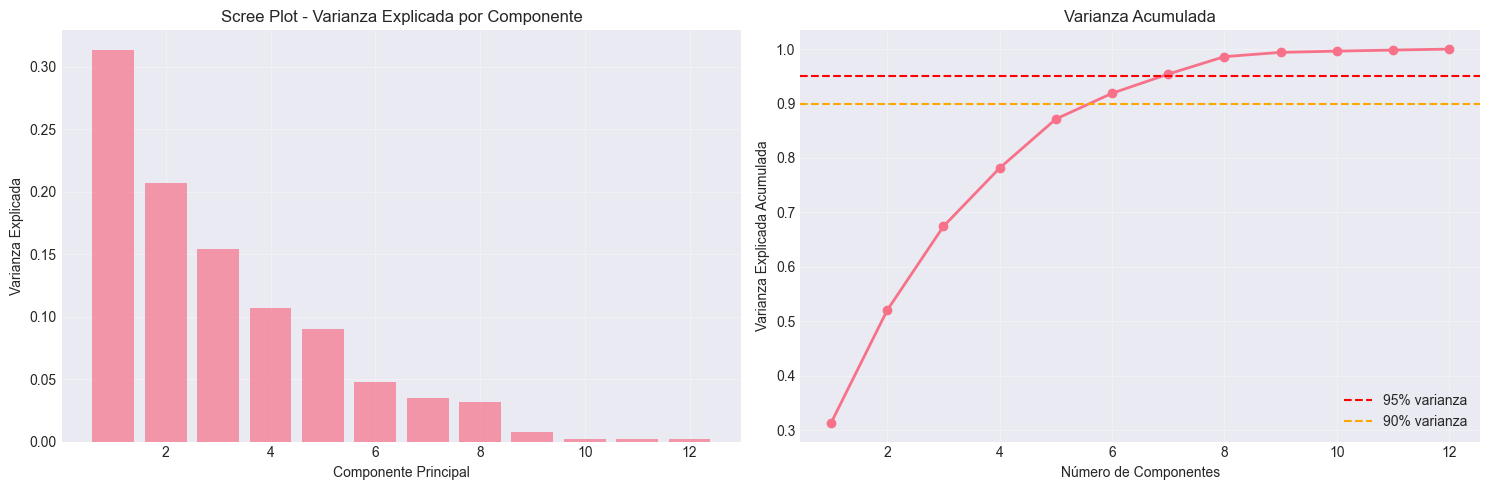


💡 Componentes necesarias para:
   90% varianza: 6 componentes
   95% varianza: 7 componentes


In [11]:
print("="*80)
print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("="*80)

# PCA para analizar varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada por componente
explained_var = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

print(f"\n📊 Varianza explicada por componente:")
for i, (var, cumvar) in enumerate(zip(explained_var[:10], cumsum_var[:10]), 1):
    print(f"   PC{i:2}: {var*100:5.2f}% (acumulada: {cumvar*100:5.2f}%)")

# Visualizar scree plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, alpha=0.7)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Scree Plot - Varianza Explicada por Componente')
axes[0].grid(alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, marker='o', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar número de componentes
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1

print(f"\n💡 Componentes necesarias para:")
print(f"   90% varianza: {n_components_90} componentes")
print(f"   95% varianza: {n_components_95} componentes")

In [12]:
# Aplicar PCA con número óptimo de componentes
print("="*80)
print("APLICANDO PCA")
print("="*80)

# Usar 90% de varianza explicada
N_COMPONENTS_PCA = n_components_90

print(f"\n⚙️ Reduciendo dimensionalidad a {N_COMPONENTS_PCA} componentes...")

pca = PCA(n_components=N_COMPONENTS_PCA, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"\n✓ PCA aplicado exitosamente")
print(f"   Shape original: {X_scaled.shape}")
print(f"   Shape después de PCA: {X_pca.shape}")
print(f"   Varianza explicada: {cumsum_var[N_COMPONENTS_PCA-1]*100:.2f}%")

# Crear DataFrame con componentes principales
pca_cols = [f'PC{i+1}' for i in range(N_COMPONENTS_PCA)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols)

print(f"\n📊 Primeras filas del espacio PCA:")
print(X_pca_df.head())

APLICANDO PCA

⚙️ Reduciendo dimensionalidad a 6 componentes...

✓ PCA aplicado exitosamente
   Shape original: (15407, 12)
   Shape después de PCA: (15407, 6)
   Varianza explicada: 91.88%

📊 Primeras filas del espacio PCA:
        PC1       PC2       PC3       PC4       PC5       PC6
0  1.733976  0.573084  1.284860 -2.216018 -0.483059 -0.488800
1  0.456572  0.537869  1.160575 -2.068500 -0.067909  0.156920
2  0.898175  1.200881  0.171132 -2.424451 -0.307430  0.617429
3  1.667338  0.614720  0.483419 -2.527266 -0.323455  0.888489
4 -0.089290  1.452735  0.601263 -2.058429 -0.164983 -0.217680


## 5. Clustering con K-Means

K-Means es ideal para encontrar grupos esféricos y compactos.
Usaremos el método del codo y silhouette score para determinar el número óptimo de clusters.

In [13]:
print("="*80)
print("K-MEANS: BÚSQUEDA DEL NÚMERO ÓPTIMO DE CLUSTERS")
print("="*80)

# Probar diferentes números de clusters
K_RANGE = range(2, 11)

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print(f"\n⚙️ Probando K-Means con K = {K_RANGE[0]} a {K_RANGE[-1]}...\n")

for k in K_RANGE:
    # Entrenar K-Means
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    # Métricas
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_pca, labels)
    db_score = davies_bouldin_score(X_pca, labels)
    ch_score = calinski_harabasz_score(X_pca, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)
    
    print(f"K={k:2} | Inertia: {inertia:10.2f} | Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f} | Calinski-Harabasz: {ch_score:.2f}")

print("\n✓ Evaluación completada")

K-MEANS: BÚSQUEDA DEL NÚMERO ÓPTIMO DE CLUSTERS

⚙️ Probando K-Means con K = 2 a 10...

K= 2 | Inertia:  135632.85 | Silhouette: 0.2317 | Davies-Bouldin: 1.7334 | Calinski-Harabasz: 3889.38
K= 3 | Inertia:  115486.48 | Silhouette: 0.2030 | Davies-Bouldin: 1.6244 | Calinski-Harabasz: 3627.34
K= 4 | Inertia:  100707.82 | Silhouette: 0.2243 | Davies-Bouldin: 1.3995 | Calinski-Harabasz: 3526.34
K= 5 | Inertia:   86835.94 | Silhouette: 0.2397 | Davies-Bouldin: 1.2451 | Calinski-Harabasz: 3682.16
K= 6 | Inertia:   77065.11 | Silhouette: 0.2570 | Davies-Bouldin: 1.1581 | Calinski-Harabasz: 3709.52
K= 7 | Inertia:   68198.22 | Silhouette: 0.2717 | Davies-Bouldin: 1.1209 | Calinski-Harabasz: 3826.67
K= 8 | Inertia:   61692.46 | Silhouette: 0.2594 | Davies-Bouldin: 1.0877 | Calinski-Harabasz: 3857.64
K= 9 | Inertia:   55149.44 | Silhouette: 0.2741 | Davies-Bouldin: 1.0431 | Calinski-Harabasz: 4004.02
K=10 | Inertia:   50414.65 | Silhouette: 0.2950 | Davies-Bouldin: 1.0332 | Calinski-Harabasz: 40

VISUALIZACIÓN DE MÉTRICAS - K-MEANS


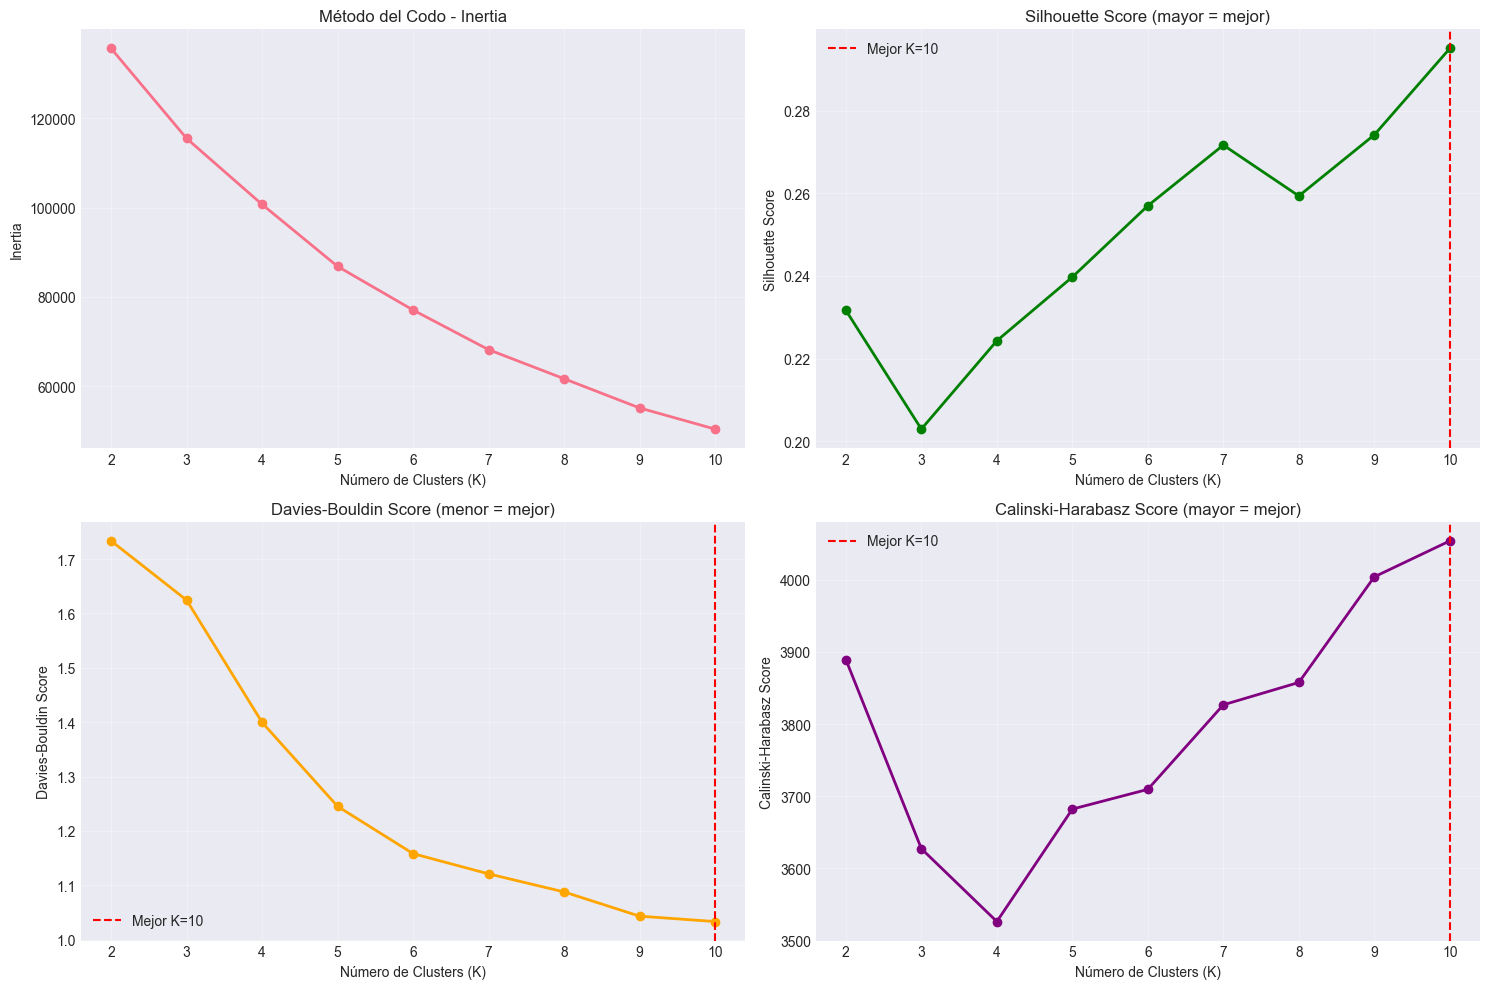


💡 Mejores valores de K según cada métrica:
   Silhouette Score: K = 10
   Davies-Bouldin: K = 10
   Calinski-Harabasz: K = 10

✓ K óptimo seleccionado: 10


In [14]:
# Visualizar métricas
print("="*80)
print("VISUALIZACIÓN DE MÉTRICAS - K-MEANS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Método del codo (Inertia)
axes[0, 0].plot(K_RANGE, inertias, marker='o', linewidth=2)
axes[0, 0].set_xlabel('Número de Clusters (K)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Método del Codo - Inertia')
axes[0, 0].grid(alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[0, 1].plot(K_RANGE, silhouette_scores, marker='o', color='green', linewidth=2)
best_k_sil = K_RANGE[np.argmax(silhouette_scores)]
axes[0, 1].axvline(x=best_k_sil, color='red', linestyle='--', label=f'Mejor K={best_k_sil}')
axes[0, 1].set_xlabel('Número de Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (mayor = mejor)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Davies-Bouldin Score (menor es mejor)
axes[1, 0].plot(K_RANGE, davies_bouldin_scores, marker='o', color='orange', linewidth=2)
best_k_db = K_RANGE[np.argmin(davies_bouldin_scores)]
axes[1, 0].axvline(x=best_k_db, color='red', linestyle='--', label=f'Mejor K={best_k_db}')
axes[1, 0].set_xlabel('Número de Clusters (K)')
axes[1, 0].set_ylabel('Davies-Bouldin Score')
axes[1, 0].set_title('Davies-Bouldin Score (menor = mejor)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Calinski-Harabasz Score (mayor es mejor)
axes[1, 1].plot(K_RANGE, calinski_harabasz_scores, marker='o', color='purple', linewidth=2)
best_k_ch = K_RANGE[np.argmax(calinski_harabasz_scores)]
axes[1, 1].axvline(x=best_k_ch, color='red', linestyle='--', label=f'Mejor K={best_k_ch}')
axes[1, 1].set_xlabel('Número de Clusters (K)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].set_title('Calinski-Harabasz Score (mayor = mejor)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Mejores valores de K según cada métrica:")
print(f"   Silhouette Score: K = {best_k_sil}")
print(f"   Davies-Bouldin: K = {best_k_db}")
print(f"   Calinski-Harabasz: K = {best_k_ch}")

# Seleccionar K óptimo (promedio o votación)
K_OPTIMAL = best_k_sil  # O usar votación/promedio
print(f"\n✓ K óptimo seleccionado: {K_OPTIMAL}")

In [15]:
# Entrenar K-Means con K óptimo
print("="*80)
print(f"K-MEANS FINAL (K={K_OPTIMAL})")
print("="*80)

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=SEED, n_init=20)
labels_kmeans = kmeans_final.fit_predict(X_pca)

print(f"\n✓ K-Means entrenado con K={K_OPTIMAL}")
print(f"\n📊 Distribución de clusters:")
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    pct = (count / len(labels_kmeans)) * 100
    print(f"   Cluster {cluster}: {count:6,} observaciones ({pct:5.2f}%)")

# Métricas finales
sil_final = silhouette_score(X_pca, labels_kmeans)
db_final = davies_bouldin_score(X_pca, labels_kmeans)
ch_final = calinski_harabasz_score(X_pca, labels_kmeans)

print(f"\n📈 Métricas del modelo final:")
print(f"   Silhouette Score: {sil_final:.4f}")
print(f"   Davies-Bouldin Score: {db_final:.4f}")
print(f"   Calinski-Harabasz Score: {ch_final:.2f}")

K-MEANS FINAL (K=10)

✓ K-Means entrenado con K=10

📊 Distribución de clusters:
   Cluster 0:  2,867 observaciones (18.61%)
   Cluster 1:  1,526 observaciones ( 9.90%)
   Cluster 2:  1,092 observaciones ( 7.09%)
   Cluster 3:  4,961 observaciones (32.20%)
   Cluster 4:    552 observaciones ( 3.58%)
   Cluster 5:    464 observaciones ( 3.01%)
   Cluster 6:    604 observaciones ( 3.92%)
   Cluster 7:    294 observaciones ( 1.91%)
   Cluster 8:  2,482 observaciones (16.11%)
   Cluster 9:    565 observaciones ( 3.67%)

📈 Métricas del modelo final:
   Silhouette Score: 0.2950
   Davies-Bouldin Score: 1.0332
   Calinski-Harabasz Score: 4053.81


## 6. Clustering con Gaussian Mixture Models (GMM)

GMM es un modelo probabilístico que asume que los datos provienen de una mezcla de distribuciones gaussianas.
Permite asignaciones "suaves" (probabilidades de pertenencia).

In [16]:
print("="*80)
print("GAUSSIAN MIXTURE MODELS (GMM)")
print("="*80)

# Probar diferentes números de componentes
N_COMPONENTS_RANGE = range(2, 11)

bic_scores = []
aic_scores = []

print(f"\n⚙️ Probando GMM con {N_COMPONENTS_RANGE[0]} a {N_COMPONENTS_RANGE[-1]} componentes...\n")

for n_comp in N_COMPONENTS_RANGE:
    gmm = GaussianMixture(n_components=n_comp, covariance_type='full', random_state=SEED, n_init=10)
    gmm.fit(X_pca)
    
    bic = gmm.bic(X_pca)
    aic = gmm.aic(X_pca)
    
    bic_scores.append(bic)
    aic_scores.append(aic)
    
    print(f"N={n_comp:2} | BIC: {bic:12.2f} | AIC: {aic:12.2f}")

# Mejor número de componentes (menor BIC/AIC)
best_n_bic = N_COMPONENTS_RANGE[np.argmin(bic_scores)]
best_n_aic = N_COMPONENTS_RANGE[np.argmin(aic_scores)]

print(f"\n💡 Mejor número de componentes:")
print(f"   Según BIC: {best_n_bic}")
print(f"   Según AIC: {best_n_aic}")

GAUSSIAN MIXTURE MODELS (GMM)

⚙️ Probando GMM con 2 a 10 componentes...

N= 2 | BIC:    258641.47 | AIC:    258221.13
N= 3 | BIC:    220210.36 | AIC:    219576.02
N= 4 | BIC:    200092.93 | AIC:    199244.60
N= 5 | BIC:    188200.49 | AIC:    187138.17
N= 6 | BIC:    182220.42 | AIC:    180944.11
N= 7 | BIC:    136557.12 | AIC:    135066.82
N= 8 | BIC:    131770.69 | AIC:    130066.40
N= 9 | BIC:    127419.94 | AIC:    125501.65
N=10 | BIC:    115749.03 | AIC:    113616.75

💡 Mejor número de componentes:
   Según BIC: 10
   Según AIC: 10


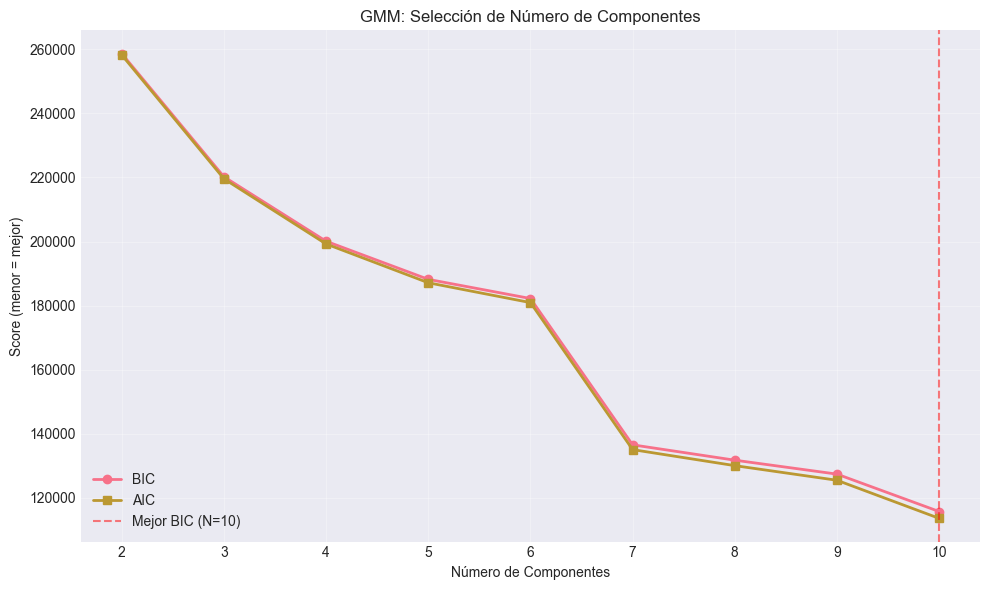

In [17]:
# Visualizar BIC y AIC
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(N_COMPONENTS_RANGE, bic_scores, marker='o', label='BIC', linewidth=2)
ax.plot(N_COMPONENTS_RANGE, aic_scores, marker='s', label='AIC', linewidth=2)
ax.axvline(x=best_n_bic, color='red', linestyle='--', alpha=0.5, label=f'Mejor BIC (N={best_n_bic})')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Score (menor = mejor)')
ax.set_title('GMM: Selección de Número de Componentes')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Entrenar GMM con número óptimo
print("="*80)
print(f"GMM FINAL (N={best_n_bic} componentes)")
print("="*80)

N_COMPONENTS_GMM = best_n_bic

gmm_final = GaussianMixture(
    n_components=N_COMPONENTS_GMM,
    covariance_type='full',
    random_state=SEED,
    n_init=20
)
gmm_final.fit(X_pca)

# Asignaciones hard (cluster con mayor probabilidad)
labels_gmm = gmm_final.predict(X_pca)

# Probabilidades de pertenencia (soft assignments)
probs_gmm = gmm_final.predict_proba(X_pca)

print(f"\n✓ GMM entrenado con {N_COMPONENTS_GMM} componentes")
print(f"\n📊 Distribución de clusters (hard assignments):")
unique, counts = np.unique(labels_gmm, return_counts=True)
for cluster, count in zip(unique, counts):
    pct = (count / len(labels_gmm)) * 100
    print(f"   Cluster {cluster}: {count:6,} observaciones ({pct:5.2f}%)")

# Métricas
sil_gmm = silhouette_score(X_pca, labels_gmm)
db_gmm = davies_bouldin_score(X_pca, labels_gmm)
ch_gmm = calinski_harabasz_score(X_pca, labels_gmm)

print(f"\n📈 Métricas del modelo final:")
print(f"   Silhouette Score: {sil_gmm:.4f}")
print(f"   Davies-Bouldin Score: {db_gmm:.4f}")
print(f"   Calinski-Harabasz Score: {ch_gmm:.2f}")
print(f"   BIC: {gmm_final.bic(X_pca):.2f}")
print(f"   AIC: {gmm_final.aic(X_pca):.2f}")

GMM FINAL (N=10 componentes)

✓ GMM entrenado con 10 componentes

📊 Distribución de clusters (hard assignments):
   Cluster 0:    690 observaciones ( 4.48%)
   Cluster 1:  4,337 observaciones (28.15%)
   Cluster 2:  1,706 observaciones (11.07%)
   Cluster 3:  2,470 observaciones (16.03%)
   Cluster 4:  2,436 observaciones (15.81%)
   Cluster 5:    979 observaciones ( 6.35%)
   Cluster 6:    856 observaciones ( 5.56%)
   Cluster 7:    553 observaciones ( 3.59%)
   Cluster 8:    338 observaciones ( 2.19%)
   Cluster 9:  1,042 observaciones ( 6.76%)

📈 Métricas del modelo final:
   Silhouette Score: 0.1038
   Davies-Bouldin Score: 2.1640
   Calinski-Harabasz Score: 1632.78
   BIC: 115749.03
   AIC: 113616.75


## 7. Clustering con DBSCAN

DBSCAN (Density-Based Spatial Clustering) detecta clusters de forma arbitraria y outliers.
No requiere especificar el número de clusters de antemano.

DBSCAN: CLUSTERING BASADO EN DENSIDAD

⚙️ Calculando k-distance para determinar eps...


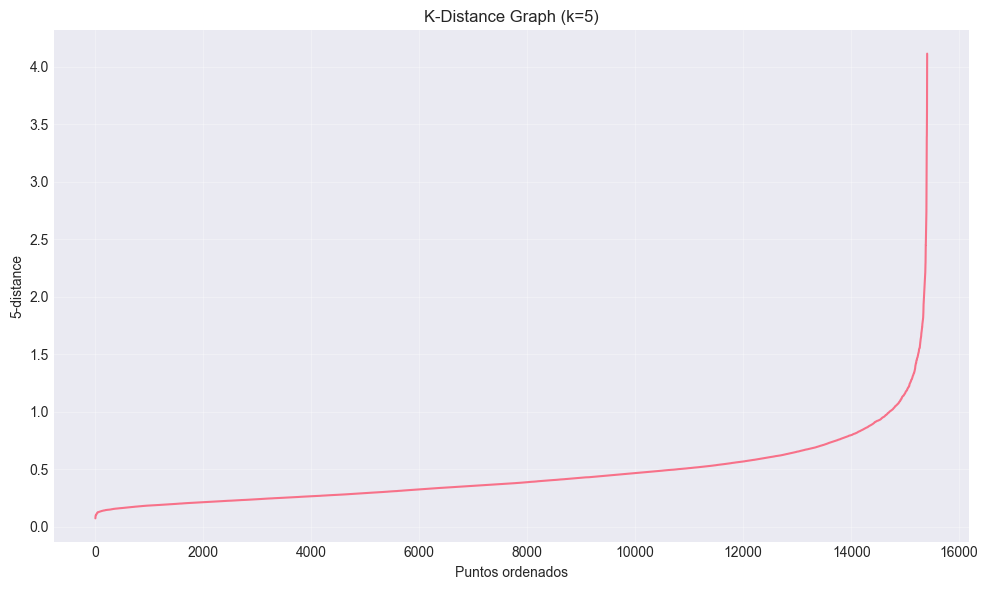


💡 Eps sugerido (percentil 90): 0.7719


In [19]:
print("="*80)
print("DBSCAN: CLUSTERING BASADO EN DENSIDAD")
print("="*80)

# Buscar epsilon óptimo
# Usar k-distance graph para determinar eps
from sklearn.neighbors import NearestNeighbors

print("\n⚙️ Calculando k-distance para determinar eps...")

k = 5  # min_samples típico
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

# Distancias al k-ésimo vecino más cercano
k_distances = np.sort(distances[:, -1])

# Visualizar k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'{k}-distance')
plt.title(f'K-Distance Graph (k={k})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Sugerir eps basado en el "codo" del gráfico
# Tomar el percentil 90 como estimación
eps_suggested = np.percentile(k_distances, 90)
print(f"\n💡 Eps sugerido (percentil 90): {eps_suggested:.4f}")

In [20]:
# Probar diferentes valores de eps
print("="*80)
print("PROBANDO DIFERENTES PARÁMETROS DBSCAN")
print("="*80)

EPS_RANGE = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
MIN_SAMPLES = 5

print(f"\nmin_samples = {MIN_SAMPLES}\n")

dbscan_results = []

for eps in EPS_RANGE:
    dbscan = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels_db = dbscan.fit_predict(X_pca)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    
    # Métricas solo si hay más de 1 cluster
    if n_clusters > 1:
        # Excluir ruido para métricas
        mask = labels_db != -1
        if mask.sum() > 0:
            sil = silhouette_score(X_pca[mask], labels_db[mask])
        else:
            sil = -1
    else:
        sil = -1
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': (n_noise / len(labels_db)) * 100,
        'silhouette': sil
    })
    
    print(f"eps={eps:4.2f} | Clusters: {n_clusters:2} | Ruido: {n_noise:6} ({(n_noise/len(labels_db))*100:5.2f}%) | Silhouette: {sil:6.4f}")

# Convertir a DataFrame
dbscan_df = pd.DataFrame(dbscan_results)

# Seleccionar mejor eps (balance entre clusters y ruido)
# Filtrar resultados válidos (con clusters y silhouette > 0)
valid_results = dbscan_df[(dbscan_df['n_clusters'] > 1) & (dbscan_df['silhouette'] > 0)]

if len(valid_results) > 0:
    best_eps_idx = valid_results['silhouette'].idxmax()
    EPS_OPTIMAL = dbscan_df.loc[best_eps_idx, 'eps']
    print(f"\n💡 Eps óptimo seleccionado: {EPS_OPTIMAL}")
else:
    EPS_OPTIMAL = eps_suggested
    print(f"\n⚠️ No se encontró eps óptimo, usando sugerencia: {EPS_OPTIMAL:.4f}")

PROBANDO DIFERENTES PARÁMETROS DBSCAN

min_samples = 5

eps=0.50 | Clusters: 97 | Ruido:   3184 (20.67%) | Silhouette: -0.0994
eps=0.75 | Clusters: 53 | Ruido:   1053 ( 6.83%) | Silhouette: -0.0101
eps=1.00 | Clusters: 31 | Ruido:    373 ( 2.42%) | Silhouette: 0.0061
eps=1.25 | Clusters: 12 | Ruido:    173 ( 1.12%) | Silhouette: 0.2342
eps=1.50 | Clusters:  6 | Ruido:     84 ( 0.55%) | Silhouette: 0.3302
eps=2.00 | Clusters:  3 | Ruido:     28 ( 0.18%) | Silhouette: 0.4028

💡 Eps óptimo seleccionado: 2.0


In [21]:
# Entrenar DBSCAN final
print("="*80)
print(f"DBSCAN FINAL (eps={EPS_OPTIMAL}, min_samples={MIN_SAMPLES})")
print("="*80)

dbscan_final = DBSCAN(eps=EPS_OPTIMAL, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan_final.fit_predict(X_pca)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = list(labels_dbscan).count(-1)

print(f"\n✓ DBSCAN entrenado")
print(f"   Clusters encontrados: {n_clusters_db}")
print(f"   Puntos de ruido (outliers): {n_noise_db} ({(n_noise_db/len(labels_dbscan))*100:.2f}%)")

print(f"\n📊 Distribución de clusters:")
unique, counts = np.unique(labels_dbscan, return_counts=True)
for cluster, count in zip(unique, counts):
    pct = (count / len(labels_dbscan)) * 100
    cluster_name = 'Ruido' if cluster == -1 else f'Cluster {cluster}'
    print(f"   {cluster_name:12}: {count:6,} observaciones ({pct:5.2f}%)")

# Métricas (excluyendo ruido)
if n_clusters_db > 1:
    mask = labels_dbscan != -1
    sil_db = silhouette_score(X_pca[mask], labels_dbscan[mask])
    db_db = davies_bouldin_score(X_pca[mask], labels_dbscan[mask])
    ch_db = calinski_harabasz_score(X_pca[mask], labels_dbscan[mask])
    
    print(f"\n📈 Métricas (excluyendo ruido):")
    print(f"   Silhouette Score: {sil_db:.4f}")
    print(f"   Davies-Bouldin Score: {db_db:.4f}")
    print(f"   Calinski-Harabasz Score: {ch_db:.2f}")

DBSCAN FINAL (eps=2.0, min_samples=5)

✓ DBSCAN entrenado
   Clusters encontrados: 3
   Puntos de ruido (outliers): 28 (0.18%)

📊 Distribución de clusters:
   Ruido       :     28 observaciones ( 0.18%)
   Cluster 0   : 14,699 observaciones (95.40%)
   Cluster 1   :    552 observaciones ( 3.58%)
   Cluster 2   :    128 observaciones ( 0.83%)

📈 Métricas (excluyendo ruido):
   Silhouette Score: 0.4028
   Davies-Bouldin Score: 0.9250
   Calinski-Harabasz Score: 1401.07


## 8. Visualización con t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica de reducción de dimensionalidad
especialmente útil para visualizar datos de alta dimensión en 2D/3D.

In [22]:
print("="*80)
print("t-SNE: REDUCCIÓN DE DIMENSIONALIDAD PARA VISUALIZACIÓN")
print("="*80)

# Aplicar t-SNE
print(f"\n⚙️ Aplicando t-SNE...")
print(f"   Esto puede tomar varios minutos dependiendo del tamaño del dataset...")

# Para datasets grandes, usar una muestra
if len(X_pca) > 5000:
    print(f"\n⚠️ Dataset grande ({len(X_pca)} puntos), usando muestra de 5000 para t-SNE")
    sample_idx = np.random.choice(len(X_pca), 5000, replace=False)
    X_pca_sample = X_pca[sample_idx]
    labels_kmeans_sample = labels_kmeans[sample_idx]
    labels_gmm_sample = labels_gmm[sample_idx]
    labels_dbscan_sample = labels_dbscan[sample_idx]
    y_true_sample = y_true.iloc[sample_idx]
else:
    X_pca_sample = X_pca
    labels_kmeans_sample = labels_kmeans
    labels_gmm_sample = labels_gmm
    labels_dbscan_sample = labels_dbscan
    y_true_sample = y_true

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=SEED,
    verbose=1
)

X_tsne = tsne.fit_transform(X_pca_sample)

print(f"\n✓ t-SNE completado")
print(f"   Shape: {X_tsne.shape}")

t-SNE: REDUCCIÓN DE DIMENSIONALIDAD PARA VISUALIZACIÓN

⚙️ Aplicando t-SNE...
   Esto puede tomar varios minutos dependiendo del tamaño del dataset...

⚠️ Dataset grande (15407 puntos), usando muestra de 5000 para t-SNE


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 9. Visualización Comparativa de Algoritmos

In [ ]:
print("="*80)
print("VISUALIZACIÓN COMPARATIVA")
print("="*80)

# Crear visualización 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. K-Means
scatter1 = axes[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels_kmeans_sample, cmap='tab10', 
                              alpha=0.6, s=20)
axes[0, 0].set_title(f'K-Means (K={K_OPTIMAL})\nSilhouette: {sil_final:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# 2. GMM
scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels_gmm_sample, cmap='tab10', 
                              alpha=0.6, s=20)
axes[0, 1].set_title(f'Gaussian Mixture Model (N={N_COMPONENTS_GMM})\nSilhouette: {sil_gmm:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# 3. DBSCAN
scatter3 = axes[1, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels_dbscan_sample, cmap='tab10', 
                              alpha=0.6, s=20)
axes[1, 0].set_title(f'DBSCAN (eps={EPS_OPTIMAL}, min_samples={MIN_SAMPLES})\nClusters: {n_clusters_db}, Ruido: {(n_noise_db/len(labels_dbscan))*100:.1f}%', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster (-1=ruido)')

# 4. Rendimiento real (ground truth)
scatter4 = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=y_true_sample, cmap='viridis', 
                              alpha=0.6, s=20)
axes[1, 1].set_title('Rendimiento Real (ground truth)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
plt.colorbar(scatter4, ax=axes[1, 1], label='Rendimiento')

plt.suptitle('Comparación de Algoritmos de Clustering (visualización t-SNE)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Visualización generada")

## 10. Comparación de Métricas de Todos los Algoritmos

In [ ]:
print("="*80)
print("COMPARACIÓN DE ALGORITMOS")
print("="*80)

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Algoritmo': ['K-Means', 'GMM', 'DBSCAN'],
    'N Clusters': [K_OPTIMAL, N_COMPONENTS_GMM, n_clusters_db],
    'Silhouette': [sil_final, sil_gmm, sil_db if n_clusters_db > 1 else np.nan],
    'Davies-Bouldin': [db_final, db_gmm, db_db if n_clusters_db > 1 else np.nan],
    'Calinski-Harabasz': [ch_final, ch_gmm, ch_db if n_clusters_db > 1 else np.nan],
    'Puntos Ruido': [0, 0, n_noise_db],
    '% Ruido': [0, 0, (n_noise_db/len(labels_dbscan))*100]
})

print("\n📊 Tabla Comparativa:")
print(comparison_df.to_string(index=False))

print("\n💡 Interpretación de métricas:")
print("   Silhouette Score: Mayor es mejor (rango: -1 a 1)")
print("   Davies-Bouldin: Menor es mejor (rango: 0 a ∞)")
print("   Calinski-Harabasz: Mayor es mejor (rango: 0 a ∞)")

# Determinar mejor algoritmo
print("\n" + "="*80)
print("MEJOR ALGORITMO POR MÉTRICA")
print("="*80)

best_sil = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algoritmo']
best_db = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algoritmo']
best_ch = comparison_df.loc[comparison_df['Calinski-Harabasz'].idxmax(), 'Algoritmo']

print(f"\n   Silhouette Score: {best_sil}")
print(f"   Davies-Bouldin: {best_db}")
print(f"   Calinski-Harabasz: {best_ch}")

## 11. Análisis de Clusters: Características por Grupo

In [ ]:
print("="*80)
print("ANÁLISIS DE CARACTERÍSTICAS POR CLUSTER (K-MEANS)")
print("="*80)

# Agregar labels al dataset original
df_agg['cluster_kmeans'] = labels_kmeans
df_agg['cluster_gmm'] = labels_gmm
df_agg['cluster_dbscan'] = labels_dbscan

# Analizar características de cada cluster K-Means
print("\n📊 CARACTERÍSTICAS PROMEDIO POR CLUSTER (K-MEANS):\n")

for cluster in range(K_OPTIMAL):
    cluster_data = df_agg[df_agg['cluster_kmeans'] == cluster]
    
    print(f"{'='*80}")
    print(f"CLUSTER {cluster} ({len(cluster_data)} observaciones)")
    print(f"{'='*80}")
    
    # Estadísticas de features clave
    print(f"\n  Clima:")
    print(f"    Temperatura media: {cluster_data['temperatura_celsius_mean'].mean():.2f}°C")
    print(f"    Precipitación media: {cluster_data['precipitacion_mm_mean'].mean():.2f} mm")
    print(f"    Precipitación total: {cluster_data['precipitacion_mm_sum'].mean():.2f} mm")
    
    print(f"\n  Suelo:")
    print(f"    Índice productividad: {cluster_data['suelo_ind_prod_first'].mean():.2f}")
    print(f"    Profundidad: {cluster_data['suelo_profund_s1_first'].mean():.2f}")
    
    print(f"\n  Rendimiento:")
    print(f"    Media: {cluster_data['rendimiento_mean'].mean():.2f}")
    print(f"    Mediana: {cluster_data['rendimiento_mean'].median():.2f}")
    print(f"    Std: {cluster_data['rendimiento_mean'].std():.2f}")
    
    # Distribución geográfica
    print(f"\n  Distribución geográfica (top 5 provincias):")
    top_provincias = cluster_data['provincia_nombre_first'].value_counts().head(5)
    for prov, count in top_provincias.items():
        pct = (count / len(cluster_data)) * 100
        print(f"    {prov}: {count} ({pct:.1f}%)")
    
    print()

In [ ]:
# Visualizar distribución de rendimiento por cluster
print("="*80)
print("DISTRIBUCIÓN DE RENDIMIENTO POR CLUSTER")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
df_agg.boxplot(column='rendimiento_mean', by='cluster_kmeans', ax=axes[0])
axes[0].set_title('K-Means')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Rendimiento')
axes[0].get_figure().suptitle('')

# GMM
df_agg.boxplot(column='rendimiento_mean', by='cluster_gmm', ax=axes[1])
axes[1].set_title('GMM')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rendimiento')
axes[1].get_figure().suptitle('')

# DBSCAN
df_agg.boxplot(column='rendimiento_mean', by='cluster_dbscan', ax=axes[2])
axes[2].set_title('DBSCAN')
axes[2].set_xlabel('Cluster (-1=ruido)')
axes[2].set_ylabel('Rendimiento')
axes[2].get_figure().suptitle('')

plt.suptitle('Distribución de Rendimiento por Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Generación de Features de Clustering

In [ ]:
print("="*80)
print("GENERACIÓN DE FEATURES DE CLUSTERING")
print("="*80)

# Crear dataset con features de clustering
print("\n⚙️ Creando features de clustering...")

# 1. Labels de clustering (one-hot encoding)
from sklearn.preprocessing import OneHotEncoder

# K-Means one-hot
kmeans_onehot = pd.get_dummies(df_agg['cluster_kmeans'], prefix='kmeans_cluster')

# GMM one-hot
gmm_onehot = pd.get_dummies(df_agg['cluster_gmm'], prefix='gmm_cluster')

# DBSCAN one-hot (incluye ruido)
dbscan_onehot = pd.get_dummies(df_agg['cluster_dbscan'], prefix='dbscan_cluster')

# 2. Probabilidades de GMM (soft assignments)
probs_df = pd.DataFrame(probs_gmm, columns=[f'gmm_prob_{i}' for i in range(N_COMPONENTS_GMM)])

# 3. Distancia a centroides K-Means
distances_kmeans = kmeans_final.transform(X_pca)
distances_df = pd.DataFrame(distances_kmeans, columns=[f'kmeans_dist_{i}' for i in range(K_OPTIMAL)])

# 4. Componentes PCA
pca_df = pd.DataFrame(X_pca, columns=[f'pca_{i}' for i in range(N_COMPONENTS_PCA)])

# Combinar todo
features_clustering = pd.concat([
    df_agg.reset_index(drop=True),
    kmeans_onehot,
    gmm_onehot,
    dbscan_onehot,
    probs_df,
    distances_df,
    pca_df
], axis=1)

print(f"\n✓ Features de clustering generadas")
print(f"   Shape: {features_clustering.shape}")
print(f"   Columnas totales: {len(features_clustering.columns)}")

print(f"\n📊 Nuevas features creadas:")
print(f"   K-Means one-hot: {len(kmeans_onehot.columns)}")
print(f"   GMM one-hot: {len(gmm_onehot.columns)}")
print(f"   DBSCAN one-hot: {len(dbscan_onehot.columns)}")
print(f"   GMM probabilidades: {len(probs_df.columns)}")
print(f"   K-Means distancias: {len(distances_df.columns)}")
print(f"   PCA componentes: {len(pca_df.columns)}")
print(f"   Total nuevas features: {len(kmeans_onehot.columns) + len(gmm_onehot.columns) + len(dbscan_onehot.columns) + len(probs_df.columns) + len(distances_df.columns) + len(pca_df.columns)}")

## 13. Guardar Resultados

In [ ]:
print("="*80)
print("GUARDADO DE RESULTADOS")
print("="*80)

import os
import pickle

# Crear directorio
output_dir = 'data/processed/clustering'
os.makedirs(output_dir, exist_ok=True)

# 1. Guardar dataset con features de clustering
print("\n💾 Guardando dataset con features de clustering...")
features_clustering.to_csv(f'{output_dir}/dataset_with_clustering_features.csv', index=False)
print(f"   ✓ dataset_with_clustering_features.csv")

# 2. Guardar modelos
print("\n💾 Guardando modelos...")
with open(f'{output_dir}/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"   ✓ kmeans_model.pkl")

with open(f'{output_dir}/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)
print(f"   ✓ gmm_model.pkl")

with open(f'{output_dir}/dbscan_model.pkl', 'wb') as f:
    pickle.dump(dbscan_final, f)
print(f"   ✓ dbscan_model.pkl")

# 3. Guardar PCA y scaler
with open(f'{output_dir}/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)
print(f"   ✓ pca_model.pkl")

with open(f'{output_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"   ✓ scaler.pkl")

# 4. Guardar métricas y configuración
config = {
    'feature_cols': feature_cols,
    'k_optimal': K_OPTIMAL,
    'n_components_gmm': N_COMPONENTS_GMM,
    'eps_dbscan': EPS_OPTIMAL,
    'min_samples_dbscan': MIN_SAMPLES,
    'n_components_pca': N_COMPONENTS_PCA,
    'cultivo': CULTIVO_SELECCIONADO,
    'metrics': {
        'kmeans': {'silhouette': sil_final, 'davies_bouldin': db_final, 'calinski_harabasz': ch_final},
        'gmm': {'silhouette': sil_gmm, 'davies_bouldin': db_gmm, 'calinski_harabasz': ch_gmm},
        'dbscan': {'silhouette': sil_db if n_clusters_db > 1 else None, 'n_clusters': n_clusters_db, 'n_noise': n_noise_db}
    }
}

with open(f'{output_dir}/clustering_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print(f"   ✓ clustering_config.pkl")

# 5. Guardar tabla comparativa
comparison_df.to_csv(f'{output_dir}/algorithms_comparison.csv', index=False)
print(f"   ✓ algorithms_comparison.csv")

print(f"\n✓ Todos los archivos guardados en: {output_dir}/")

## 14. Resumen Final

In [ ]:
print("="*80)
print("RESUMEN FINAL - ANÁLISIS DE CLUSTERING")
print("="*80)

print(f"""
✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 DATOS:
   • Cultivo: {CULTIVO_SELECCIONADO if CULTIVO_SELECCIONADO else 'Todos'}
   • Total observaciones: {len(df_agg):,}
   • Features originales: {len(feature_cols)}
   • Componentes PCA: {N_COMPONENTS_PCA} ({cumsum_var[N_COMPONENTS_PCA-1]*100:.1f}% varianza)

🔍 ALGORITMOS APLICADOS:

   1. K-MEANS:
      • Clusters: {K_OPTIMAL}
      • Silhouette: {sil_final:.4f}
      • Davies-Bouldin: {db_final:.4f}
      • Calinski-Harabasz: {ch_final:.2f}
   
   2. GAUSSIAN MIXTURE MODEL:
      • Componentes: {N_COMPONENTS_GMM}
      • Silhouette: {sil_gmm:.4f}
      • Davies-Bouldin: {db_gmm:.4f}
      • Calinski-Harabasz: {ch_gmm:.2f}
      • BIC: {gmm_final.bic(X_pca):.2f}
   
   3. DBSCAN:
      • Epsilon: {EPS_OPTIMAL}
      • Min samples: {MIN_SAMPLES}
      • Clusters encontrados: {n_clusters_db}
      • Puntos de ruido: {n_noise_db} ({(n_noise_db/len(labels_dbscan))*100:.1f}%)

🎯 MEJOR ALGORITMO (por métricas):
   • Silhouette: {best_sil}
   • Davies-Bouldin: {best_db}
   • Calinski-Harabasz: {best_ch}

💾 ARCHIVOS GENERADOS:
   • {output_dir}/dataset_with_clustering_features.csv
   • {output_dir}/kmeans_model.pkl
   • {output_dir}/gmm_model.pkl
   • {output_dir}/dbscan_model.pkl
   • {output_dir}/pca_model.pkl
   • {output_dir}/scaler.pkl
   • {output_dir}/clustering_config.pkl
   • {output_dir}/algorithms_comparison.csv

🚀 NUEVAS FEATURES GENERADAS:
   • {len(kmeans_onehot.columns)} features K-Means (one-hot)
   • {len(gmm_onehot.columns)} features GMM (one-hot)
   • {len(dbscan_onehot.columns)} features DBSCAN (one-hot)
   • {len(probs_df.columns)} probabilidades GMM
   • {len(distances_df.columns)} distancias K-Means
   • {len(pca_df.columns)} componentes PCA

💡 USO DE LAS FEATURES:
   Las features de clustering pueden usarse como:
   1. Variables categóricas adicionales en modelos
   2. Features para estratificación/agrupación
   3. Base para modelos específicos por cluster
   4. Detección de regiones/años atípicos (DBSCAN ruido)

   Ejemplo:
   df = pd.read_csv('{output_dir}/dataset_with_clustering_features.csv')
   
   # Usar clusters como features
   cluster_features = [col for col in df.columns if 'cluster' in col]
   
   # Entrenar modelo específico por cluster
   for cluster in df['cluster_kmeans'].unique():
       df_cluster = df[df['cluster_kmeans'] == cluster]
       # Entrenar modelo...

🔄 PRÓXIMOS PASOS:
   1. Usar clusters como features en modelos predictivos
   2. Entrenar modelos específicos por cluster
   3. Analizar características distintivas de cada grupo
   4. Identificar regiones/años con patrones similares
   5. Detectar outliers y analizar casos extremos
   6. Combinar con features de RNN para modelo final

""")

print("="*80)
print("ANÁLISIS DE CLUSTERING COMPLETADO ✅")
print("="*80)